In [46]:
import os
import glob
import warnings
import numpy as np
import pretty_midi
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Reshape, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Suppress pretty_midi RuntimeWarnings to keep the console output clean
warnings.filterwarnings("ignore", category=RuntimeWarning, module="pretty_midi")

# Project Constants
TARGET_COMPOSERS = ['bach', 'beethoven', 'chopin', 'mozart']
FS = 100               # Sampling frequency (100 frames per second)
SEQUENCE_LENGTH = 1500 # 15-second time windows (1500 time-steps)

In [47]:
def load_midi_safely(file_path):
    """Attempts to load a MIDI file, returning None if corrupted."""
    try:
        return pretty_midi.PrettyMIDI(file_path)
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
        return None

def midi_to_piano_roll(midi_data, fs=FS):
    """Converts MIDI to a normalized 2D piano roll."""
    if midi_data is None:
        return None
    piano_roll = midi_data.get_piano_roll(fs=fs)
    return piano_roll / 127.0 # Normalize velocities (0.0 to 1.0)

def build_dataset(data_directory):
    """Scans directory, filters by target composer, and extracts piano rolls."""
    features, labels = [], []
    search_pattern = os.path.join(data_directory, '**', '*.[mM][iI][dD]*')
    all_midi_files = glob.glob(search_pattern, recursive=True)

    print(f"Found {len(all_midi_files)} total MIDI files. Processing...")

    for file_path in all_midi_files:
        filename = os.path.basename(file_path).lower()
        composer_label = next((c for c in TARGET_COMPOSERS if c in filename), None)

        if composer_label:
            midi_data = load_midi_safely(file_path)
            piano_roll = midi_to_piano_roll(midi_data)

            if piano_roll is not None:
                features.append(piano_roll)
                labels.append(composer_label)

    print(f"Successfully processed {len(features)} files.")
    return features, labels

# Execute Data Loading (Update this path to your actual dataset folder)
dataset_path = '/content/drive/MyDrive/AAI_511_FinalProject /data/'
X_raw, y_raw = build_dataset(dataset_path)

Found 3920 total MIDI files. Processing...
Successfully processed 21 files.


In [48]:
def create_sequences(features, labels, seq_length=SEQUENCE_LENGTH):
    """Slices variable-length piano rolls into fixed-length sequential windows."""
    X_seq, y_seq = [], []

    for i in range(len(features)):
        piano_roll = features[i]
        label = labels[i]
        time_steps = piano_roll.shape[1]

        for start_idx in range(0, time_steps - seq_length, seq_length):
            segment = piano_roll[:, start_idx : start_idx + seq_length]
            X_seq.append(np.transpose(segment)) # Transpose to (time_steps, pitches)
            y_seq.append(label)

    return np.array(X_seq), np.array(y_seq)

def prepare_data(X_raw, y_raw):
    """Orchestrates sequencing, encoding, and splitting."""
    # 1. Create sequences
    X_seq, y_seq = create_sequences(X_raw, y_raw)

    # 2. Encode string labels to one-hot arrays
    encoder = LabelEncoder()
    y_integers = encoder.fit_transform(y_seq)
    y_one_hot = to_categorical(y_integers, num_classes=len(encoder.classes_))

    print(f"Class Mapping: {dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))}")

    # 3. Split into 70% Train, 15% Validation, 15% Test
    X_train, X_temp, y_train, y_temp = train_test_split(X_seq, y_one_hot, test_size=0.30, random_state=42, stratify=y_one_hot)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

    return X_train, X_val, X_test, y_train, y_val, y_test, encoder

# Execute Preparation
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder = prepare_data(X_raw, y_raw)

Class Mapping: {np.str_('bach'): np.int64(0)}


In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Reshape, Conv2D, MaxPooling2D, Flatten

INPUT_SHAPE = (SEQUENCE_LENGTH, 128)
NUM_CLASSES = len(TARGET_COMPOSERS)

def build_lstm_model():
    """Compiles the temporal LSTM sequence model."""
    model = Sequential([
        Input(shape=INPUT_SHAPE),
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(128),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    # FIX: Changed to sparse_categorical_crossentropy
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_cnn_model():
    """Compiles the spatial 2D CNN classification model."""
    model = Sequential([
        Input(shape=INPUT_SHAPE),
        Reshape((INPUT_SHAPE[0], INPUT_SHAPE[1], 1)),
        Conv2D(32, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        Conv2D(64, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    # FIX: Changed to sparse_categorical_crossentropy
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_lstm_model()
cnn_model = build_cnn_model()

print("Models successfully compiled with sparse categorical crossentropy.")

Models successfully compiled with sparse categorical crossentropy.


In [41]:
# Define optimization callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.0001)
]

# Train LSTM
print("Training LSTM...")
lstm_history = lstm_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=32, callbacks=callbacks)

# Train CNN
print("\nTraining CNN...")
cnn_history = cnn_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=32, callbacks=callbacks)

Training LSTM...
Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 7s/step - accuracy: 0.6723 - loss: 1.3148 - val_accuracy: 1.0000 - val_loss: 1.1238 - learning_rate: 0.0010
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 1.0000 - loss: 0.7864 - val_accuracy: 1.0000 - val_loss: 0.0916 - learning_rate: 0.0010
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 1.0000 - loss: 0.0340 - val_accuracy: 1.0000 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 1.0955e-04 - learning_rate: 0.0010
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 1.0000 - loss: 1.0147e-04 - val_accuracy: 1.0000 - val_loss: 2.0151e-05 - learning_rate: 0.0010
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 1.0000 - loss: 2.3634e-05 - val_accuracy: 1.0000 - val_loss: 6.1512e-06 - learning_rate: 0.0010
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 1.0000 - loss: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


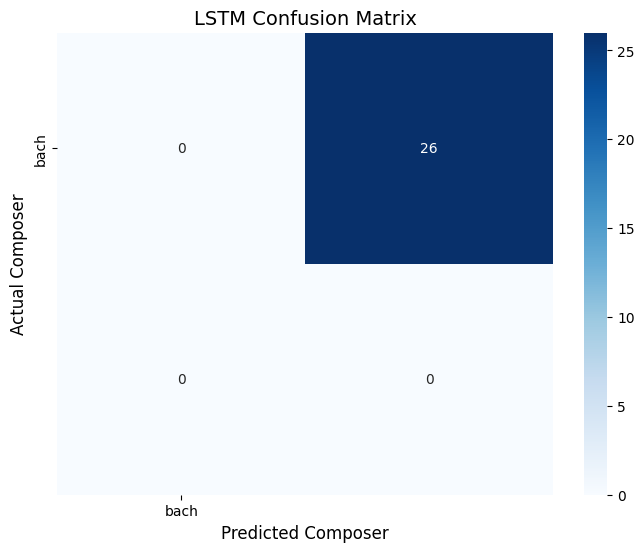

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


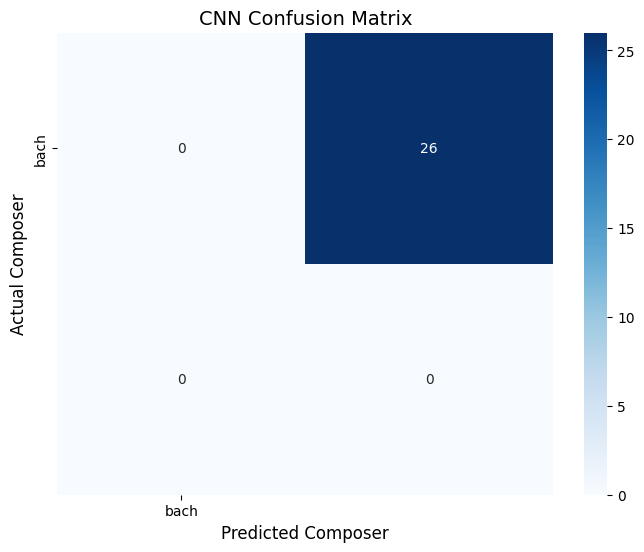

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(model, X_test, y_test, encoder, title="Confusion Matrix"):
    """
    Generates predictions and plots a heatmap of the confusion matrix.
    """
    # Generate predictions
    y_pred_probs = model.predict(X_test)
    y_pred_indices = np.argmax(y_pred_probs, axis=1)

    # Handle y_test depending on if it is 1D (integers) or 2D (one-hot)
    if y_test.ndim == 2:
        y_true_indices = np.argmax(y_test, axis=1)
    else:
        y_true_indices = y_test

    # Generate the confusion matrix
    cm = confusion_matrix(y_true_indices, y_pred_indices)

    # Plotting using Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_,
                yticklabels=encoder.classes_)

    plt.title(title, fontsize=14)
    plt.ylabel('Actual Composer', fontsize=12)
    plt.xlabel('Predicted Composer', fontsize=12)
    plt.show()

# --- Run this for both models ---
plot_confusion_matrix(lstm_model, X_test, y_test, label_encoder, title="LSTM Confusion Matrix")

plot_confusion_matrix(cnn_model, X_test, y_test, label_encoder, title="CNN Confusion Matrix")

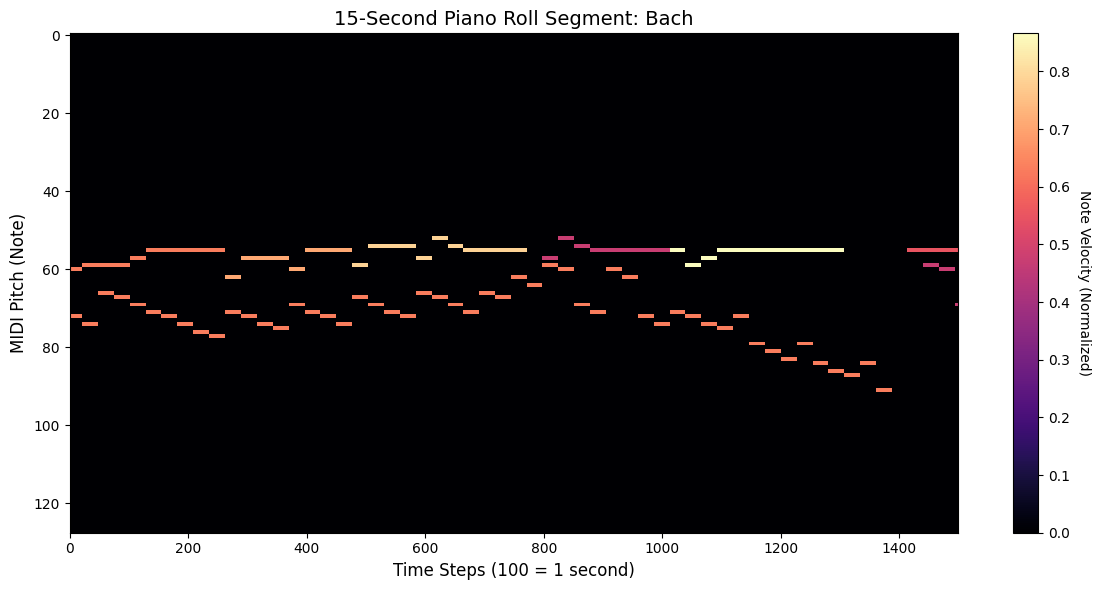

In [43]:
def plot_piano_roll(sequence, composer_name):
    """
    Takes a single 15-second music sequence (1500, 128) and plots it as an image.
    """
    plt.figure(figsize=(12, 6))

    # The sequence is currently (time_steps, pitches).
    # We transpose it back to (pitches, time_steps) so time goes left-to-right.
    # We also flip it upside down so higher pitches are at the top of the Y-axis.
    piano_roll_visual = np.flipud(np.transpose(sequence))

    # Display the matrix as an image
    plt.imshow(piano_roll_visual, aspect='auto', cmap='magma', interpolation='nearest')

    plt.title(f'15-Second Piano Roll Segment: {composer_name.capitalize()}', fontsize=14)
    plt.xlabel('Time Steps (100 = 1 second)', fontsize=12)
    plt.ylabel('MIDI Pitch (Note)', fontsize=12)

    # Add a colorbar to show the velocity (volume) scale
    cbar = plt.colorbar()
    cbar.set_label('Note Velocity (Normalized)', rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

# --- To test it, plot the very first sequence in your training data ---
# Get the integer label of the first sequence and convert it back to the string name
first_label_int = y_train[0] if y_train.ndim == 1 else np.argmax(y_train[0])
composer_str = label_encoder.inverse_transform([first_label_int])[0]

plot_piano_roll(X_train[0], composer_str)

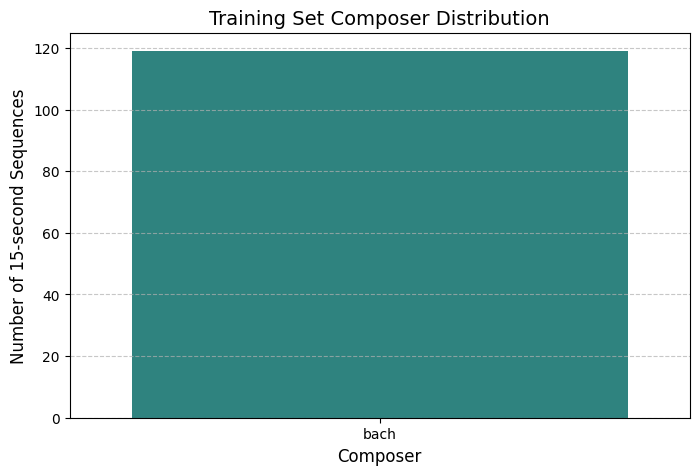

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_class_distribution(y_labels, encoder, title="Dataset Class Distribution"):
    """
    Plots a bar chart showing the number of sequences per composer.
    """
    plt.figure(figsize=(8, 5))

    # Check if labels are one-hot encoded and convert them back to integers
    if y_labels.ndim == 2:
        y_labels = np.argmax(y_labels, axis=1)

    # Convert integer labels back to the actual string names (Bach, Mozart, etc.)
    composer_names = encoder.inverse_transform(y_labels)

    # FIX: Added 'hue' and 'legend=False' to comply with the latest Seaborn update
    sns.countplot(
        x=composer_names,
        hue=composer_names,
        palette="viridis",
        order=encoder.classes_,
        legend=False
    )

    plt.title(title, fontsize=14)
    plt.xlabel("Composer", fontsize=12)
    plt.ylabel("Number of 15-second Sequences", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

# --- Run this to see the distribution of your training data ---
plot_class_distribution(y_train, label_encoder, title="Training Set Composer Distribution")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


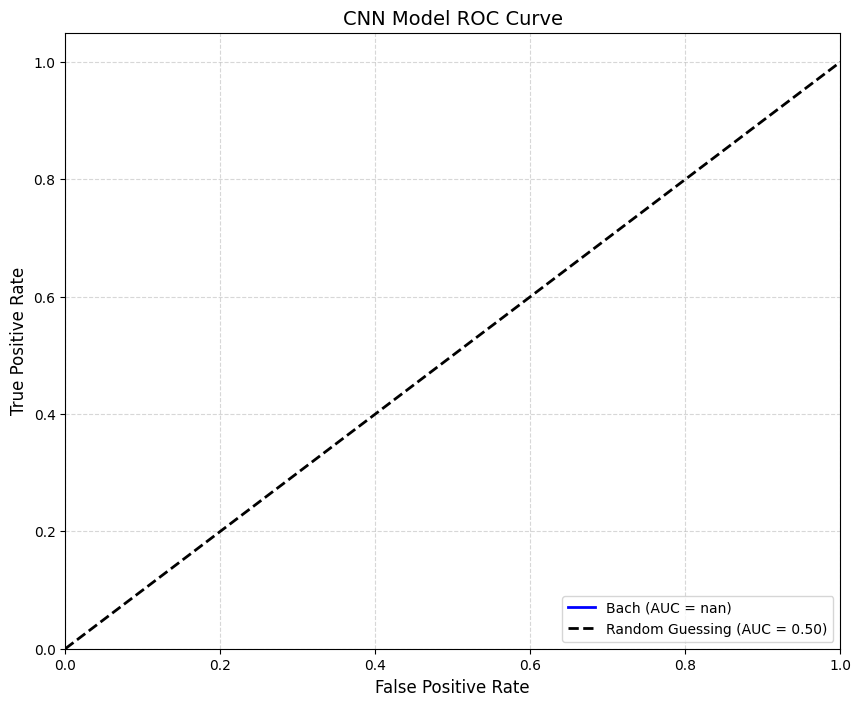

In [45]:
from sklearn.metrics import roc_curve, auc
from itertools import cycle

def plot_multiclass_roc(model, X_test, y_test, encoder, title="ROC Curve"):
    """
    Plots a multi-class Receiver Operating Characteristic (ROC) curve.
    """
    # Get the raw predicted probabilities
    y_pred_probs = model.predict(X_test)
    n_classes = len(encoder.classes_)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Calculate ROC curve and ROC area for each class
    for i in range(n_classes):
        # We compare the true one-hot vector column vs the predicted probability column
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plotting
    plt.figure(figsize=(10, 8))
    colors = cycle(['blue', 'red', 'green', 'darkorange'])

    for i, color in zip(range(n_classes), colors):
        composer = encoder.classes_[i].capitalize()
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{composer} (AUC = {roc_auc[i]:.2f})')

    # Plot the random-guess baseline
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing (AUC = 0.50)')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.show()

# --- Run this to evaluate your models ---
plot_multiclass_roc(cnn_model, X_test, y_test, label_encoder, title="CNN Model ROC Curve")